# Proyecto TEXTO - Parte 4: NLP Clásico
## Análisis de Datos No Estructurados 2025-2026

**Dataset:** Transcripciones ATC  
**Objetivo:** Análisis NLP completo 

---

##  Pipeline:

### **EDA:**
-  Distribución de datos, balanceo de clases
-  Procesamiento: stopwords, lematización
-  Representación: TF-IDF, word frequency, BoW, embeddings
-  Análisis avanzado: clustering, topic modeling

### **Machine Learning:**
-  Clasificación por categorías ATC

---

In [29]:
from pathlib import Path
NOTEBOOK_OUTPUT_DIR = Path("outputs") / "ADNE_Proyecto_Texto_Part4_NLP_Clasico"
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {NOTEBOOK_OUTPUT_DIR.resolve()}")

import sys
print("Instalando dependencias...")
!{sys.executable} -m pip install -q pandas numpy matplotlib seaborn nltk spacy scikit-learn wordcloud datasets tqdm "scipy<1.14" gensim==4.3.2

Output directory: /Users/carolinamacho/Desktop/ICAI-Análisis_datos_no_estructurados_OC/Proyecto_ATC_Comunicaciones_Aeronauticas/outputs/ADNE_Proyecto_Texto_Part4_NLP_Clasico
Instalando dependencias...


In [30]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
print("Recursos descargados")

Recursos descargados


In [31]:
import pandas as pd
import numpy as np
import re
import warnings
from collections import Counter
from tqdm import tqdm

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

WORD2VEC_AVAILABLE = True
try:
    from gensim.models import Word2Vec
except Exception as e:
    WORD2VEC_AVAILABLE = False
    print(f"️ Word2Vec no disponible ({e}). Se omite esa sección.")

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from datasets import load_dataset

warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

SEED = 42
np.random.seed(SEED)

print("Librerías importadas")

Librerías importadas


##  Cargar Datos

In [32]:
from datasets import load_dataset
from tqdm import tqdm
import pandas as pd

print(" Cargando ATCOSIM...")
ds = load_dataset("Jzuluaga/atcosim_corpus")
train_data = ds['train'] if 'train' in ds else ds[list(ds.keys())[0]]
print(f" {len(train_data)} muestras")

def categorize_atc(text):
    if not isinstance(text, str): return 'other'
    t = text.lower()
    if any(w in t for w in ['takeoff', 'departure']): return 'takeoff'
    if any(w in t for w in ['landing', 'approach']): return 'landing'
    if any(w in t for w in ['climb', 'descend', 'altitude', 'turn']): return 'routing'
    if any(w in t for w in ['roger', 'wilco', 'affirm']): return 'readback'
    if any(w in t for w in ['hold', 'wait']): return 'holding'
    if any(w in t for w in ['contact', 'frequency']): return 'frequency_change'
    return 'other'

texts, categories = [], []
for i in tqdm(range(min(1500, len(train_data))), desc="Extrayendo"):
    text = ""
    for key in ['text', 'transcript', 'transcription']:
        if key in train_data[i]:
            text = str(train_data[i][key])
            break
    if text:
        texts.append(text)
        categories.append(categorize_atc(text))

df = pd.DataFrame({'text': texts, 'category': categories})
print(f"\n DataFrame: {len(df)} muestras")
print(f"\n Categorías:\n{df['category'].value_counts()}")

 Cargando ATCOSIM...
 7638 muestras


Extrayendo: 100%|██████████| 1500/1500 [00:13<00:00, 115.06it/s]


 DataFrame: 1500 muestras

 Categorías:
category
other               701
frequency_change    382
routing             373
readback             44
Name: count, dtype: int64


##  EDA - Distribución y Balance

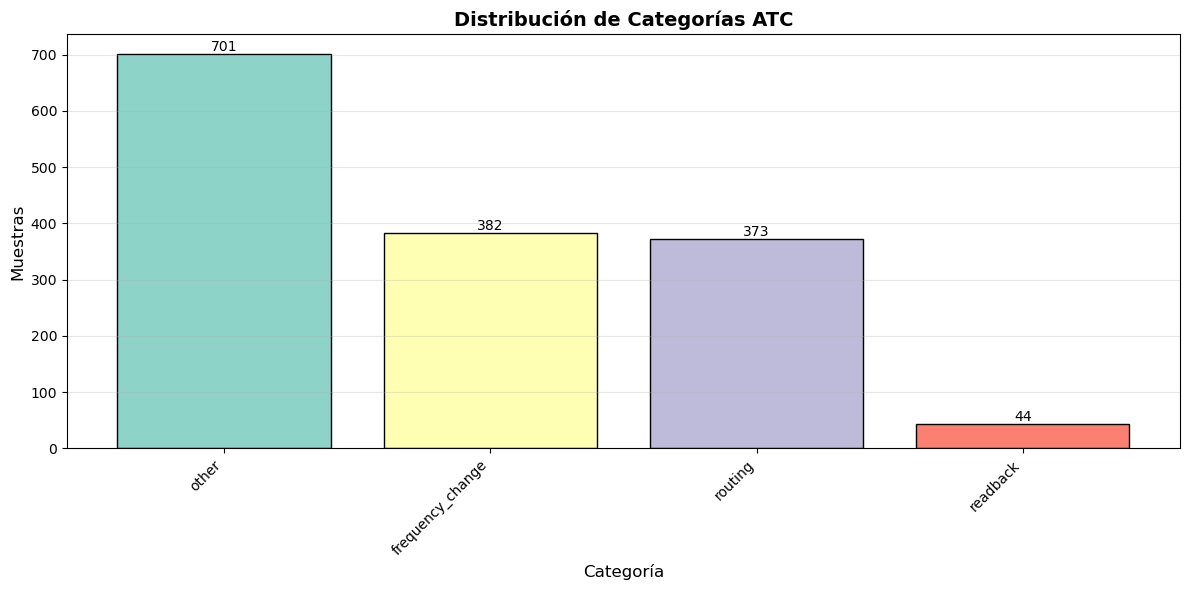


 Estadísticas:
       text_length   word_count
count  1500.000000  1500.000000
mean     59.552667    10.464000
std      21.672541     3.909334
min       2.000000     1.000000
25%      45.000000     8.000000
50%      61.000000    11.000000
75%      71.000000    13.000000
max     174.000000    32.000000


In [33]:
plt.figure(figsize=(12, 6))
counts = df['category'].value_counts()
colors = plt.cm.Set3(range(len(counts)))
bars = plt.bar(range(len(counts)), counts.values, color=colors, edgecolor='black')
plt.xticks(range(len(counts)), counts.index, rotation=45, ha='right')
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Muestras', fontsize=12)
plt.title('Distribución de Categorías ATC', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., h, f'{int(h)}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()
print(f"\n Estadísticas:\n{df[['text_length', 'word_count']].describe()}")

##  Procesamiento de Texto

In [34]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_text)

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = word_tokenize(text, preserve_line=True)
    return ' '.join([w for w in words if w not in stop_words and len(w) > 2])

df['text_no_stop'] = df['text_clean'].apply(remove_stopwords)

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = word_tokenize(text, preserve_line=True)
    return ' '.join([lemmatizer.lemmatize(w) for w in words])

print(" Lematizando...")
df['text_processed'] = df['text_no_stop'].apply(lemmatize_text)

print("\n Procesamiento completado")
print(f"\nEjemplo:")
print(f"Original:    {df['text'].iloc[0]}")
print(f"Procesado:   {df['text_processed'].iloc[0]}")

 Lematizando...

 Procesamiento completado

Ejemplo:
Original:    psa eight one zero turn right to trasadingen
Procesado:   psa eight one zero turn right trasadingen


##  Representación de Texto

 Top 20 palabras:

  three               :  1065
  one                 :  1051
  two                 :   981
  four                :   789
  zero                :   702
  seven               :   655
  five                :   620
  six                 :   570
  rhein               :   440
  contact             :   395
  identified          :   365
  nine                :   339
  eight               :   327
  decimal             :   299
  radar               :   277
  level               :   254
  flight              :   240
  lufthansa           :   232
  climb               :   226
  zurich              :   165


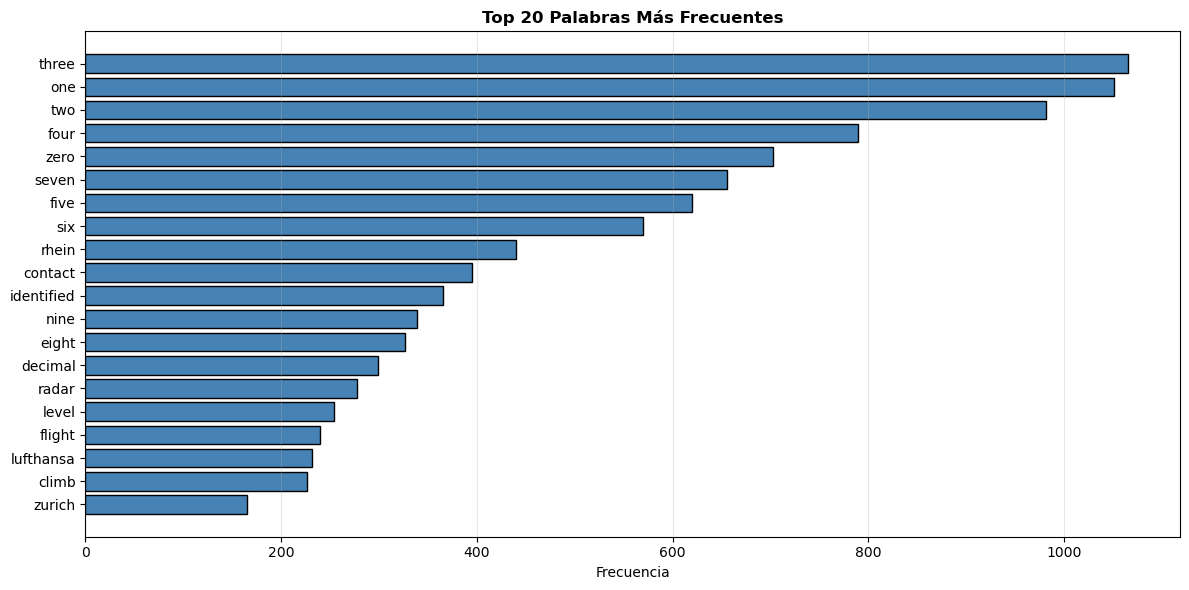

In [35]:
all_words = ' '.join(df['text_processed']).split()
word_freq = Counter(all_words)
top_20 = word_freq.most_common(20)

print(" Top 20 palabras:\n")
for word, count in top_20:
    print(f"  {word:20s}: {count:5d}")

words, counts = zip(*top_20)
plt.figure(figsize=(12, 6))
plt.barh(range(len(words)), counts, color='steelblue', edgecolor='black')
plt.yticks(range(len(words)), words)
plt.xlabel('Frecuencia')
plt.title('Top 20 Palabras Más Frecuentes', fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

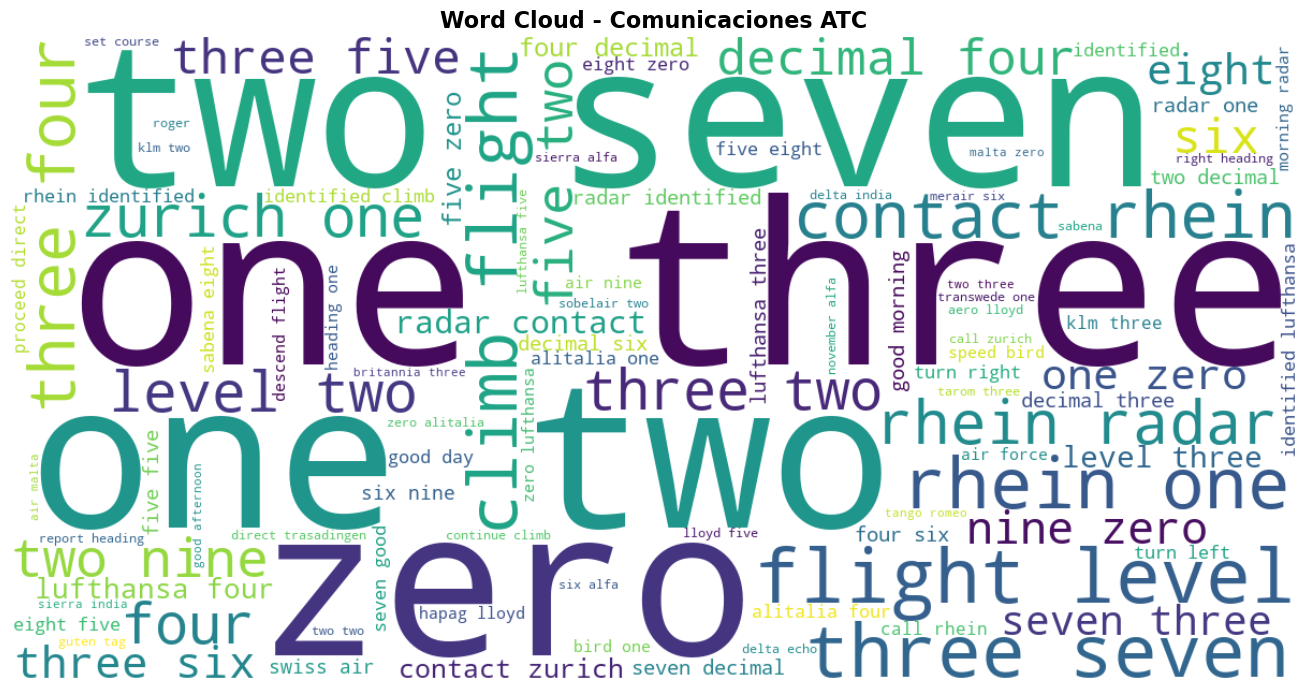

In [36]:
text_all = ' '.join(df['text_processed'])
wc = WordCloud(width=1200, height=600, background_color='white', 
               colormap='viridis', max_words=100).generate(text_all)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Comunicaciones ATC', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
print(" Calculando TF-IDF...")
tfidf = TfidfVectorizer(max_features=100, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(df['text_processed'])

print(f" Shape: {tfidf_matrix.shape}")

feature_names = tfidf.get_feature_names_out()
scores = tfidf_matrix.sum(axis=0).A1
top_indices = scores.argsort()[-20:][::-1]

print("\nTop 20 TF-IDF:\n")
for idx in top_indices:
    print(f"  {feature_names[idx]:25s}: {scores[idx]:.4f}")

 Calculando TF-IDF...
 Shape: (1500, 100)

Top 20 TF-IDF:

  one                      : 159.7603
  three                    : 150.8168
  two                      : 150.7987
  four                     : 140.5326
  seven                    : 129.2058
  zero                     : 128.4105
  five                     : 123.1309
  six                      : 108.9862
  identified               : 105.8537
  rhein                    : 94.8606
  eight                    : 89.4653
  contact                  : 81.2217
  nine                     : 79.1176
  radar                    : 73.5017
  one three                : 65.0490
  decimal                  : 62.6759
  one two                  : 59.6175
  lufthansa                : 58.1795
  level                    : 58.1217
  flight                   : 55.7291


In [38]:
count_vec = CountVectorizer(max_features=100)
bow_matrix = count_vec.fit_transform(df['text_processed'])
print(f" Bag of Words: {bow_matrix.shape}")

 Bag of Words: (1500, 100)


In [39]:
!pip install gensim

In [40]:
!pip install scipy==1.12.0 gensim --upgrade

  Using cached gensim-4.4.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (8.4 kB)
Using cached gensim-4.4.0-cp311-cp311-macosx_11_0_arm64.whl (24.5 MB)
  Attempting uninstall: gensim
    Found existing installation: gensim 4.3.2
    Uninstalling gensim-4.3.2:
      Successfully uninstalled gensim-4.3.2


In [41]:
from gensim.models import Word2Vec

In [42]:
print(" Entrenando Word2Vec...")
sentences = [text.split() for text in df['text_processed']]
w2v = Word2Vec(sentences=sentences, vector_size=100, window=5, 
                   min_count=2, workers=4, seed=SEED)

print(f" Vocabulario: {len(w2v.wv)} palabras")

test_words = ['climb', 'landing', 'turn', 'altitude']
print("\n Palabras similares:\n")
for word in test_words:
    if word in w2v.wv:
        similar = w2v.wv.most_similar(word, topn=5)
        print(f"  '{word}':")
        for sim_word, score in similar:
            print(f"    - {sim_word}: {score:.4f}")

 Entrenando Word2Vec...
 Vocabulario: 218 palabras

 Palabras similares:

  'climb':
    - descend: 0.9982
    - direct: 0.9979
    - nine: 0.9978
    - zero: 0.9977
    - continue: 0.9977
  'turn':
    - minute: 0.9991
    - oscar: 0.9990
    - november: 0.9990
    - heading: 0.9990
    - proceed: 0.9990


##  Análisis Avanzado

 Clustering con K-Means...
 4 clusters creados

Distribución de clusters:
0    283
1    780
2    186
3    251
Name: count, dtype: int64

 Calculando t-SNE...


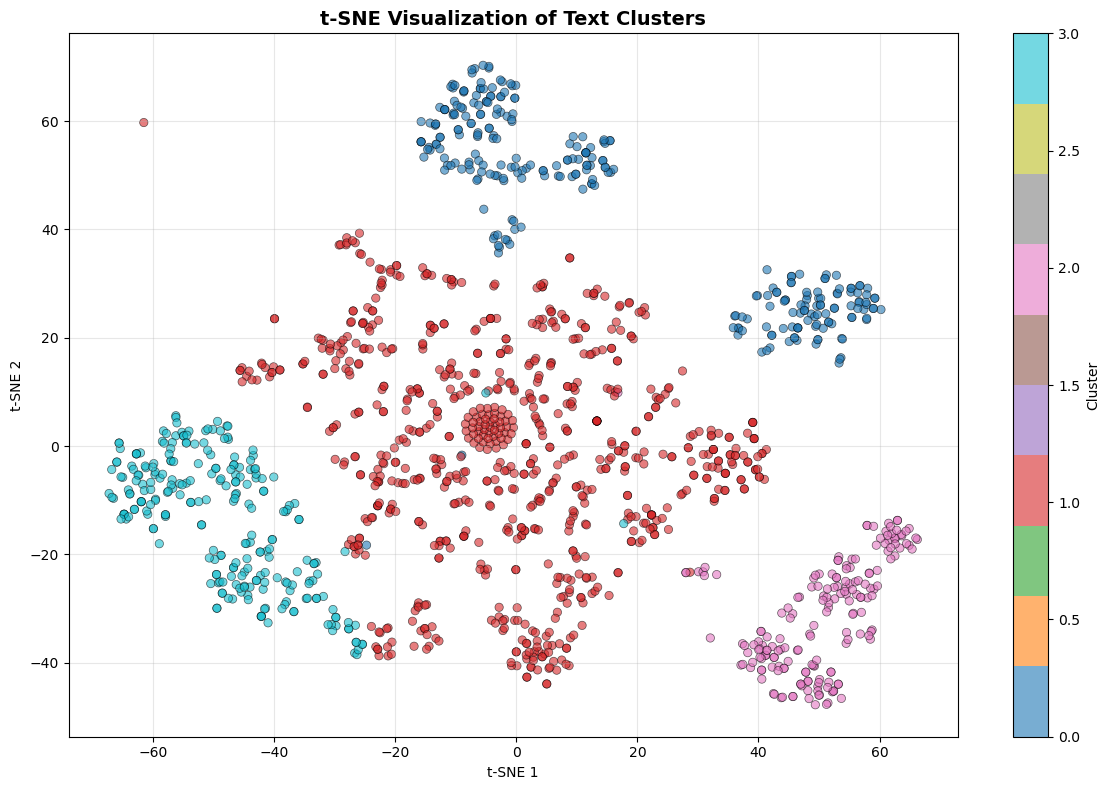

In [43]:
print(" Clustering con K-Means...")
n_clusters = len(df['category'].unique())
kmeans = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(tfidf_matrix)

df['cluster'] = clusters

print(f" {n_clusters} clusters creados")
print(f"\nDistribución de clusters:\n{pd.Series(clusters).value_counts().sort_index()}")

print("\n Calculando t-SNE...")
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
coords = tsne.fit_transform(tfidf_matrix.toarray())

plt.figure(figsize=(12, 8))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=clusters, 
                     cmap='tab10', alpha=0.6, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Cluster')
plt.title('t-SNE Visualization of Text Clusters', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
print(" Topic Modeling (LDA)...")
n_topics = 5
lda = LatentDirichletAllocation(n_components=n_topics, random_state=SEED, max_iter=20)
lda.fit(bow_matrix)

print(f"\n {n_topics} topics descubiertos\n")

feature_names_bow = count_vec.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words = [feature_names_bow[i] for i in top_words_idx]
    print(f"Topic {topic_idx}: {', '.join(top_words)}")

 Topic Modeling (LDA)...

 5 topics descubiertos

Topic 0: one, turn, heading, five, identified, alfa, eight, zero, right, hotel
Topic 1: two, seven, one, three, rhein, contact, four, radar, decimal, five
Topic 2: delta, india, echo, descend, sierra, flight, level, hundred, bravo, three
Topic 3: four, one, three, six, zurich, alitalia, contact, identified, five, decimal
Topic 4: zero, two, three, five, lufthansa, nine, level, climb, flight, six


##  Machine Learning - Clasificación

In [45]:
le = LabelEncoder()
y = le.fit_transform(df['category'])

X_train, X_test, y_train, y_test = train_test_split(
    tfidf_matrix, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f" Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

 Train: 1200, Test: 300



 NAIVE BAYES

Test Accuracy: 0.9300

Classification Report:
                  precision    recall  f1-score   support

frequency_change       0.87      0.99      0.93        76
           other       0.95      0.92      0.93       140
        readback       0.00      0.00      0.00         9
         routing       0.96      1.00      0.98        75

        accuracy                           0.93       300
       macro avg       0.70      0.73      0.71       300
    weighted avg       0.90      0.93      0.92       300



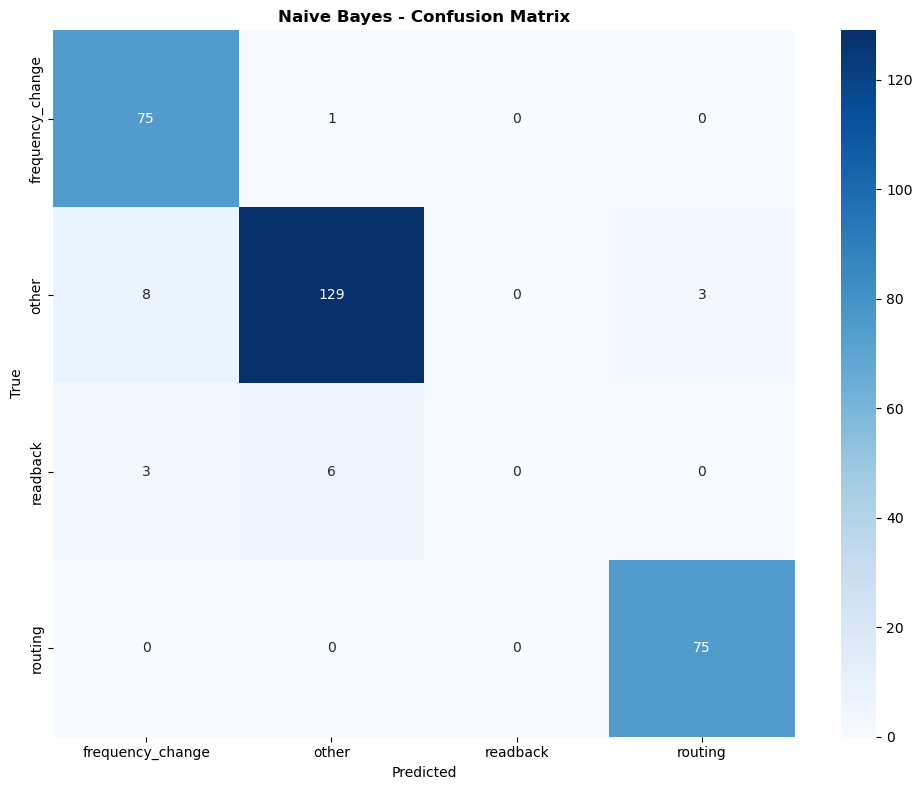

In [46]:
print("\n" + "="*80)
print(" NAIVE BAYES")
print("="*80)

nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)

print(f"\nTest Accuracy: {acc_nb:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_nb, target_names=le.classes_)}")

cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Naive Bayes - Confusion Matrix', fontweight='bold')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


 LOGISTIC REGRESSION

Test Accuracy: 0.9600

Classification Report:
                  precision    recall  f1-score   support

frequency_change       0.96      0.99      0.97        76
           other       0.95      0.99      0.97       140
        readback       0.00      0.00      0.00         9
         routing       0.97      1.00      0.99        75

        accuracy                           0.96       300
       macro avg       0.72      0.74      0.73       300
    weighted avg       0.93      0.96      0.95       300



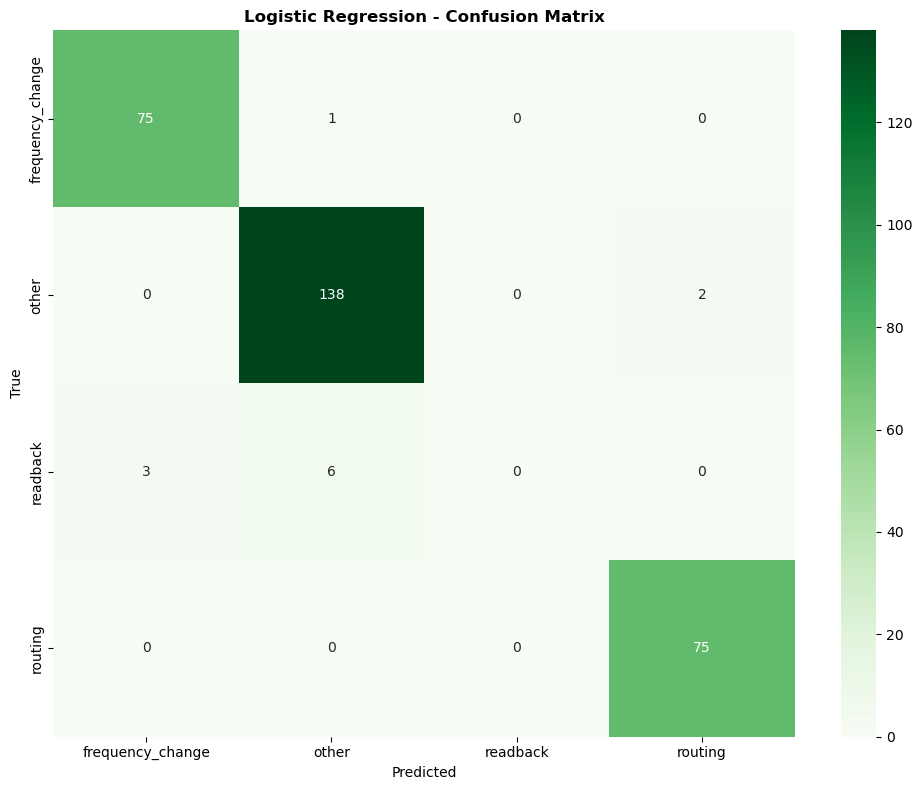

In [47]:
print("\n" + "="*80)
print(" LOGISTIC REGRESSION")
print("="*80)

lr = LogisticRegression(max_iter=1000, random_state=SEED)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"\nTest Accuracy: {acc_lr:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_lr, target_names=le.classes_)}")

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Logistic Regression - Confusion Matrix', fontweight='bold')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [48]:
print("\n" + "="*80)
print(" RANDOM FOREST")
print("="*80)

rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"\nTest Accuracy: {acc_rf:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_rf, target_names=le.classes_)}")


 RANDOM FOREST

Test Accuracy: 0.9633

Classification Report:
                  precision    recall  f1-score   support

frequency_change       0.96      1.00      0.98        76
           other       0.96      0.99      0.97       140
        readback       0.00      0.00      0.00         9
         routing       0.97      1.00      0.99        75

        accuracy                           0.96       300
       macro avg       0.72      0.75      0.73       300
    weighted avg       0.93      0.96      0.95       300



##  Comparación Final


 COMPARACIÓN ML CLÁSICO - TEXTO
              Model  Test Accuracy
        Naive Bayes       0.930000
Logistic Regression       0.960000
      Random Forest       0.963333


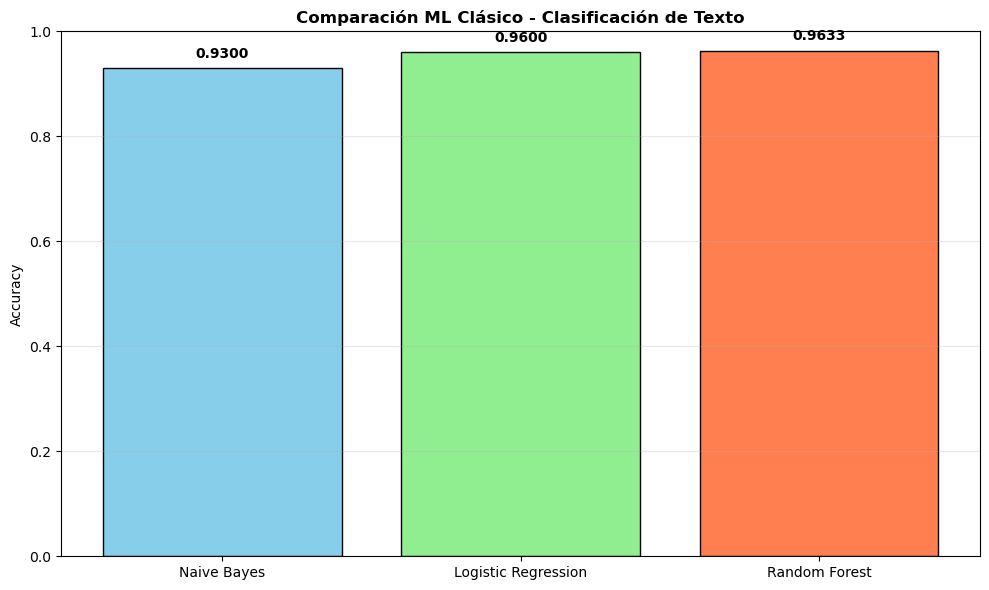

In [49]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression', 'Random Forest'],
    'Test Accuracy': [acc_nb, acc_lr, acc_rf]
})

print("\n" + "="*80)
print(" COMPARACIÓN ML CLÁSICO - TEXTO")
print("="*80)
print(results.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.bar(results['Model'], results['Test Accuracy'], 
        color=['skyblue', 'lightgreen', 'coral'], edgecolor='black')
plt.ylabel('Accuracy')
plt.title('Comparación ML Clásico - Clasificación de Texto', fontweight='bold')
plt.ylim([0, 1])
plt.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(results['Test Accuracy']):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

##  Conclusiones

In [50]:
print("="*80)
print(" CONCLUSIONES - NOTEBOOK 4")
print("="*80)

best_model = results.loc[results['Test Accuracy'].idxmax(), 'Model']
best_acc = results['Test Accuracy'].max()

print(f"\n MEJOR MODELO: {best_model}")
print(f"   Accuracy: {best_acc:.4f}")

print(f"\n REPRESENTACIÓN DE TEXTO:")
print(f"   - TF-IDF captura importancia relativa de términos ATC")
print(f"   - Word2Vec aprende relaciones semánticas")
print(f"   - Clustering identifica grupos de comunicaciones similares")

print(f"\n PRÓXIMO PASO (Notebook 5):")
print(f"   → Deep Learning: RNN/LSTM")
print(f"   → Transfer Learning: BERT fine-tuning")
print(f"   → Comparación con ChatGPT")

print("\n" + "="*80)
print(" NOTEBOOK 4 COMPLETADO")
print("="*80)

 CONCLUSIONES - NOTEBOOK 4

 MEJOR MODELO: Random Forest
   Accuracy: 0.9633

 REPRESENTACIÓN DE TEXTO:
   - TF-IDF captura importancia relativa de términos ATC
   - Word2Vec aprende relaciones semánticas
   - Clustering identifica grupos de comunicaciones similares

 PRÓXIMO PASO (Notebook 5):
   → Deep Learning: RNN/LSTM
   → Transfer Learning: BERT fine-tuning
   → Comparación con ChatGPT

 NOTEBOOK 4 COMPLETADO


In [51]:
df.to_csv(NOTEBOOK_OUTPUT_DIR / 'atc_text_processed.csv', index=False)
print(" Datos guardados: atc_text_processed.csv")

 Datos guardados: atc_text_processed.csv
